# 503: Temperature Contribution Analysis

This notebook calculates the contribution of different forcing components to temperature change
between peak warming year and 2100.

## Approach

For each scenario with `MAGICC_FLAG="ANTHROPOGENIC"`, we calculate:
1. **Peak warming year** and **peak warming magnitude** per ensemble member
2. **Warming in 2100** per ensemble member
3. **Component contributions** (delta from peak to 2100)

### Component Lookup Rules

For a scenario `{scenario}` with `MAGICC_FLAG="ANTHROPOGENIC"`:
- **CO2/GHG**: Look up `{scenario}` with `MAGICC_FLAG=CO2` and `MAGICC_FLAG=GHG`
- **NZCO2** (for ZEC proxy): 
  - If scenario contains `_NZCO2`: use `{scenario}` with `MAGICC_FLAG=CO2`
  - If scenario contains `_NZKyoto`: use `{base}_NZCO2` with `MAGICC_FLAG=CO2` (where base = scenario without `_NZKyoto`)
  - Otherwise: use `{scenario}_NZCO2` with `MAGICC_FLAG=CO2`

### Components Analysed

- **ANTHROPOGENIC**: Total warming (from MAGICC_FLAG=ANTHROPOGENIC)
- **CO2_NZCO2**: CO2 warming if emissions held constant at net-zero level (ZEC proxy)
- **CO2_Negative**: Cooling from negative CO2 emissions (CO2 - CO2_NZCO2)
- **NonCO2_GHG**: Non-CO2 greenhouse gas contribution (GHG - CO2)
- **Residual**: Other forcings (ANTHROPOGENIC - GHG)

## Outputs

- `503_warming_metrics.csv`: Per-run metrics for all scenarios
- `503_waterfall_contributions.png`: Waterfall plots comparing scenario subsets

In [1]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
from tqdm import tqdm

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
INDIVIDUAL_RUNS_DIR = OUTPUT_FOLDER / "individual_runs"
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

In [2]:
# Configuration
MANIFEST_FILE = OUTPUT_FOLDER / "individual_runs/manifests/regenerated_manifest.csv"

COMPONENTS = ["ANTHROPOGENIC", "CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]

## Load Data

In [3]:
# Load manifest and create lookup dict
manifest = pd.read_csv(MANIFEST_FILE)
manifest["key"] = manifest["model"] + "|" + manifest["scenario"] + "|" + manifest["magicc_flag"]
file_lookup = manifest.set_index("key")["output_filename"].to_dict()

# Get all scenarios with MAGICC_FLAG="ANTHROPOGENIC" as reference scenarios
all_scenarios = manifest[manifest["magicc_flag"] == "ANTHROPOGENIC"][["model", "scenario"]].drop_duplicates()
print(f"Total reference scenarios (MAGICC_FLAG=ANTHROPOGENIC): {len(all_scenarios)}")

Total reference scenarios (MAGICC_FLAG=ANTHROPOGENIC): 9


In [4]:
def load_timeseries(filepath: Path) -> pd.DataFrame:
    """Load timeseries with run_id index and integer year columns."""
    df = pd.read_csv(filepath)
    year_cols = [c for c in df.columns if c.isdigit()]
    ts = df.set_index("run_id")[year_cols].astype(float)
    ts.columns = ts.columns.astype(int)
    return ts


def extract_at_year(ts: pd.DataFrame, run_ids: np.ndarray, years: np.ndarray) -> np.ndarray:
    """Vectorized extraction of values at specified years for each run."""
    ts_arr = ts.values
    ts_years = ts.columns.values
    ts_run_ids = ts.index.values
    
    run_to_idx = {r: i for i, r in enumerate(ts_run_ids)}
    year_to_idx = {y: i for i, y in enumerate(ts_years)}
    
    values = np.full(len(run_ids), np.nan)
    for i, (run_id, year) in enumerate(zip(run_ids, years)):
        if run_id in run_to_idx and year in year_to_idx:
            values[i] = ts_arr[run_to_idx[run_id], year_to_idx[year]]
    return values


def get_file_lookup_keys(model: str, scenario: str) -> dict:
    """
    Determine file lookup keys for a scenario.
    
    Returns dict with keys: ANTHROPOGENIC, CO2, GHG, NZCO2 (value is the lookup key). "ANTHROPOGENIC" is
    this notebook's internal/output-facing label (kept as-is throughout) - the
    manifest's actual magicc_flag value it maps to is "ANTHROPOGENIC".
    """
    keys = {
        "ANTHROPOGENIC": f"{model}|{scenario}|ANTHROPOGENIC",
        "CO2": f"{model}|{scenario}|CO2",
        "GHG": f"{model}|{scenario}|GHG",
    }
    
    # Determine NZCO2 lookup based on scenario name
    if "_NZCO2" in scenario:
        # Scenario is already NZCO2 extended - use its own CO2 flag
        keys["NZCO2"] = f"{model}|{scenario}|CO2"
    elif "_NZKyoto" in scenario:
        # NZKyoto extended - NZCO2 comes from base scenario with _NZCO2 suffix
        base_scenario = scenario.replace("_NZKyoto", "")
        keys["NZCO2"] = f"{model}|{base_scenario}_NZCO2|CO2"
    else:
        # Base scenario - NZCO2 comes from {scenario}_NZCO2
        keys["NZCO2"] = f"{model}|{scenario}_NZCO2|CO2"
    
    return keys


def calculate_peak_warming(ts_all: pd.DataFrame, start_year: int = 2020, end_year: int = 2100) -> pd.DataFrame:
    """Calculate peak warming year and magnitude for each run."""
    year_cols = [y for y in ts_all.columns if start_year <= y <= end_year]
    ts_subset = ts_all[year_cols]
    
    peak_idx = ts_subset.values.argmax(axis=1)
    peak_years = np.array(year_cols)[peak_idx]
    peak_values = ts_subset.values[np.arange(len(ts_subset)), peak_idx]
    
    return pd.DataFrame({
        "run_id": ts_all.index,
        "peak_year": peak_years,
        "peak_value": peak_values
    })

## Process Scenarios

In [5]:
results = []
missing_components = []

for _, row in tqdm(all_scenarios.iterrows(), total=len(all_scenarios), desc="Processing"):
    model, scenario = row["model"], row["scenario"]
    
    # Get file lookup keys
    keys = get_file_lookup_keys(model, scenario)
    
    # Check which files exist
    files = {k: file_lookup.get(keys[k]) for k in ["ANTHROPOGENIC", "CO2", "GHG", "NZCO2"]}
    
    # Track missing components
    missing = [k for k in ["ANTHROPOGENIC", "CO2", "GHG"] if files[k] is None]
    if missing:
        missing_components.append({"model": model, "scenario": scenario, "missing": missing})
        continue  # Skip if required components are missing
    
    has_nzco2 = files["NZCO2"] is not None
    if not has_nzco2:
        missing_components.append({"model": model, "scenario": scenario, "missing": ["NZCO2"]})
    
    # Load timeseries
    ts = {k: load_timeseries(INDIVIDUAL_RUNS_DIR / files[k]) for k in ["ANTHROPOGENIC", "CO2", "GHG"]}
    if has_nzco2:
        ts["NZCO2"] = load_timeseries(INDIVIDUAL_RUNS_DIR / files["NZCO2"])
    
    # Calculate derived components
    ts["NonCO2_GHG"] = ts["GHG"] - ts["CO2"]
    ts["Residual"] = ts["ANTHROPOGENIC"] - ts["GHG"]
    if has_nzco2:
        ts["CO2_Negative"] = ts["CO2"] - ts["NZCO2"]
    
    # Calculate peak warming from ANTHROPOGENIC timeseries
    peaks = calculate_peak_warming(ts["ANTHROPOGENIC"])
    run_ids = peaks["run_id"].values
    peak_years = peaks["peak_year"].values
    
    # Build result DataFrame
    result = pd.DataFrame({
        "model": model,
        "scenario": scenario,
        "run_id": run_ids,
        "peak_year": peak_years,
        "GSAT|ANTHROPOGENIC|peak": peaks["peak_value"].values,
        "GSAT|ANTHROPOGENIC|2100": ts["ANTHROPOGENIC"][2100].values,
    })
    
    # Extract component values at peak and 2100
    for comp_name, ts_key in [("NonCO2_GHG", "NonCO2_GHG"), ("Residual", "Residual")]:
        result[f"GSAT|{comp_name}|peak"] = extract_at_year(ts[ts_key], run_ids, peak_years)
        result[f"GSAT|{comp_name}|2100"] = ts[ts_key][2100].values
    
    if has_nzco2:
        for comp_name, ts_key in [("CO2_NZCO2", "NZCO2"), ("CO2_Negative", "CO2_Negative")]:
            result[f"GSAT|{comp_name}|peak"] = extract_at_year(ts[ts_key], run_ids, peak_years)
            result[f"GSAT|{comp_name}|2100"] = ts[ts_key][2100].values
    
    results.append(result)

metrics_df = pd.concat(results, ignore_index=True)
print(f"\nProcessed {len(metrics_df):,} runs across {len(results)} scenarios")

Processing:   0%|          | 0/9 [00:00<?, ?it/s]

Processing:  56%|█████▌    | 5/9 [00:00<00:00, 42.73it/s]

Processing: 100%|██████████| 9/9 [00:00<00:00, 43.50it/s]


Processed 225 runs across 9 scenarios


In [6]:
# select mode of extraction
EXTRACTION_YEAR_MODE = "peak_gsat"  # "peak_gsat" or "netzero_co2"

# Pre-load net-zero timings as a lookup, keyed by (model, base_scenario)
netzero_timings = pd.read_csv(OUTPUT_FOLDER / "101_netzero_timings.csv")
netzero_lookup = netzero_timings.set_index(["model", "scenario"])["year_netzero_co2"].to_dict()

results = []
missing_components = []

for _, row in tqdm(all_scenarios.iterrows(), total=len(all_scenarios), desc="Processing"):
    model, scenario = row["model"], row["scenario"]

    keys = get_file_lookup_keys(model, scenario)
    files = {k: file_lookup.get(keys[k]) for k in ["ANTHROPOGENIC", "CO2", "GHG", "NZCO2"]}

    missing = [k for k in ["ANTHROPOGENIC", "CO2", "GHG"] if files[k] is None]
    if missing:
        missing_components.append({"model": model, "scenario": scenario, "missing": missing})
        continue

    has_nzco2 = files["NZCO2"] is not None
    if not has_nzco2:
        missing_components.append({"model": model, "scenario": scenario, "missing": ["NZCO2"]})

    ts = {k: load_timeseries(INDIVIDUAL_RUNS_DIR / files[k]) for k in ["ANTHROPOGENIC", "CO2", "GHG"]}
    if has_nzco2:
        ts["NZCO2"] = load_timeseries(INDIVIDUAL_RUNS_DIR / files["NZCO2"])

    ts["NonCO2_GHG"] = ts["GHG"] - ts["CO2"]
    ts["Residual"] = ts["ANTHROPOGENIC"] - ts["GHG"]
    if has_nzco2:
        ts["CO2_Negative"] = ts["CO2"] - ts["NZCO2"]

    # Peak warming from ANTHROPOGENIC timeseries (always computed; used for ANTHROPOGENIC|peak and as default)
    peaks = calculate_peak_warming(ts["ANTHROPOGENIC"])
    run_ids = peaks["run_id"].values
    peak_gsat_years = peaks["peak_year"].values

    # Determine the extraction years for component metrics based on the flag
    if EXTRACTION_YEAR_MODE == "peak_gsat":
        extraction_years = peak_gsat_years
    elif EXTRACTION_YEAR_MODE == "netzero_co2":
        base_scenario = scenario.replace("_NZCO2", "").replace("_NZKyoto", "")
        nz_year = netzero_lookup.get((model, base_scenario))
        if nz_year is None or pd.isna(nz_year):
            missing_components.append({"model": model, "scenario": scenario, "missing": ["netzero_co2_year"]})
            continue
        extraction_years = np.full(len(run_ids), int(nz_year))
    else:
        raise ValueError(f"Unknown EXTRACTION_YEAR_MODE: {EXTRACTION_YEAR_MODE}")

    result = pd.DataFrame({
        "model": model,
        "scenario": scenario,
        "run_id": run_ids,
        "peak_year": peak_gsat_years,
        "extraction_year": extraction_years,
        "GSAT|ANTHROPOGENIC|peak": peaks["peak_value"].values,
        "GSAT|ANTHROPOGENIC|2100": ts["ANTHROPOGENIC"][2100].values,
    })

    for comp_name, ts_key in [("NonCO2_GHG", "NonCO2_GHG"), ("Residual", "Residual")]:
        result[f"GSAT|{comp_name}|peak"] = extract_at_year(ts[ts_key], run_ids, extraction_years)
        result[f"GSAT|{comp_name}|2100"] = ts[ts_key][2100].values

    if has_nzco2:
        for comp_name, ts_key in [("CO2_NZCO2", "NZCO2"), ("CO2_Negative", "CO2_Negative")]:
            result[f"GSAT|{comp_name}|peak"] = extract_at_year(ts[ts_key], run_ids, extraction_years)
            result[f"GSAT|{comp_name}|2100"] = ts[ts_key][2100].values

    results.append(result)

metrics_df = pd.concat(results, ignore_index=True)
print(f"\nProcessed {len(metrics_df):,} runs across {len(results)} scenarios")

Processing:   0%|          | 0/9 [00:00<?, ?it/s]

Processing:  56%|█████▌    | 5/9 [00:00<00:00, 45.51it/s]

Processing: 100%|██████████| 9/9 [00:00<00:00, 45.26it/s]


Processed 225 runs across 9 scenarios


In [7]:
# Report missing components
if missing_components:
    missing_df = pd.DataFrame(missing_components)
    print(f"Scenarios with missing components: {len(missing_df)}")
    print("\nBreakdown by missing component:")
    print(missing_df.explode("missing")["missing"].value_counts())
    print("\nFirst 10 examples:")
    display(missing_df.head(10))
else:
    print("All scenarios have complete component sets.")

All scenarios have complete component sets.


## Calculate Deltas

In [8]:
# Calculate deltas (2100 - peak) for all components
for comp in COMPONENTS:
    peak_col, y2100_col = f"GSAT|{comp}|peak", f"GSAT|{comp}|2100"
    if peak_col in metrics_df.columns:
        metrics_df[f"GSAT|{comp}|delta"] = metrics_df[y2100_col] - metrics_df[peak_col]

# Merge net-zero timings (using base scenario name for extended scenarios)
netzero_timings = pd.read_csv(OUTPUT_FOLDER / "101_netzero_timings.csv")

# Create base_scenario column for merging (strip _NZCO2 and _NZKyoto suffixes)
metrics_df["base_scenario"] = metrics_df["scenario"].str.replace("_NZCO2|_NZKyoto", "", regex=True)

metrics_df = metrics_df.merge(
    netzero_timings[["model", "scenario", "year_netzero_co2", "year_netzero_kyoto_ar6gwp100"]],
    left_on=["model", "base_scenario"],
    right_on=["model", "scenario"],
    how="left",
    suffixes=("", "_nz")
).drop(columns=["scenario_nz"])

print(f"Metrics shape: {metrics_df.shape}")
print(f"Unique scenarios: {metrics_df.groupby(['model', 'scenario']).ngroups}")
metrics_df.head()

Metrics shape: (225, 23)
Unique scenarios: 9


,model,scenario,run_id,peak_year,extraction_year,GSAT|ANTHROPOGENIC|peak,GSAT|ANTHROPOGENIC|2100,GSAT|NonCO2_GHG|peak,GSAT|NonCO2_GHG|2100,GSAT|Residual|peak,...,GSAT|CO2_Negative|peak,GSAT|CO2_Negative|2100,GSAT|ANTHROPOGENIC|delta,GSAT|CO2_NZCO2|delta,GSAT|CO2_Negative|delta,GSAT|NonCO2_GHG|delta,GSAT|Residual|delta,base_scenario,year_netzero_co2,year_netzero_kyoto_ar6gwp100
0,AIM/CGE 2.0,SSP1-19,0,2050,2050,1.637086,1.418872,0.039674,-0.088367,0.050311,...,0.000000,-0.082263,-0.218215,-0.036708,-0.082263,-0.128041,0.028797,SSP1-19,2056.0,2069.0
1,AIM/CGE 2.0,SSP1-19,1,2079,2079,2.559779,2.543546,0.244876,0.207509,-0.594265,...,-0.041879,-0.125407,-0.016233,0.088791,-0.083527,-0.037367,0.015870,SSP1-19,2056.0,2069.0
2,AIM/CGE 2.0,SSP1-19,2,2049,2049,1.773360,1.557116,0.048380,-0.095501,0.067849,...,0.000000,-0.087428,-0.216244,-0.005307,-0.087428,-0.143881,0.020371,SSP1-19,2056.0,2069.0
3,AIM/CGE 2.0,SSP1-19,3,2041,2041,1.382633,1.081886,0.071662,-0.123184,0.085659,...,0.000000,-0.066165,-0.300746,-0.078701,-0.066165,-0.194846,0.038966,SSP1-19,2056.0,2069.0
4,AIM/CGE 2.0,SSP1-19,4,2049,2049,1.648214,1.393853,0.114046,-0.049095,0.009753,...,0.000000,-0.079328,-0.254361,-0.059288,-0.079328,-0.163141,0.047397,SSP1-19,2056.0,2069.0


In [9]:
# Save metrics to CSV
metrics_df.to_csv(OUTPUT_FOLDER / "503_warming_metrics.csv", index=False)
print(f"Saved metrics to {OUTPUT_FOLDER / '503_warming_metrics.csv'}")

Saved metrics to /Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/503_warming_metrics.csv


## Summary Statistics

In [10]:
# Aggregate by scenario (median only for simplicity)
value_cols = [c for c in metrics_df.columns if c.startswith("GSAT|")]
stats = metrics_df.groupby(["model", "scenario"])[value_cols].median()
print(f"Statistics for {len(stats)} scenarios")
stats.round(3)

Statistics for 9 scenarios


GSAT|ANTHROPOGENIC|peak  \
model        scenario                                                                 
AIM/CGE 2.0  SSP1-19                                                          1.614   
             SSP1-19_NZCO2                                                    1.614   
             SSP1-19_NZKyoto                                                  1.614   
AIM/CGE 2.1  CD-LINKS-NPi2020_400                                             1.731   
             CD-LINKS-NPi2020_400_NZCO2                                       1.733   
             CD-LINKS-NPi2020_400_NZKyoto                                     1.731   
AIM/CGE V2.2 ENGAGE-Feasibility-1000/Institutional                            1.722   
             ENGAGE-Feasibility-1000/Institutional_NZCO2                      1.778   
             ENGAGE-Feasibility-1000/Institutional_NZKyoto                    1.722   

                                                            GSAT|ANTHROPOGENIC|2100  \
model        scenario                                                                 
AIM/CGE 2.0  SSP1-19                                                          1.315   
             SSP1-19_NZCO2                                                    1.399   
             SSP1-19_NZKyoto                                                  1.347   
AIM/CGE 2.1  CD-LINKS-NPi2020_400                                             1.269   
             CD-LINKS-NPi2020_400_NZCO2                                       1.421   
             CD-LINKS-NPi2020_400_NZKyoto                                     1.285   
AIM/CGE V2.2 ENGAGE-Feasibility-1000/Institutional                            1.622   
             ENGAGE-Feasibility-1000/Institutional_NZCO2                      1.778   
             ENGAGE-Feasibility-1000/Institutional_NZKyoto                    1.619   

                                                            GSAT|NonCO2_GHG|peak  \
model        scenario                                                              
AIM/CGE 2.0  SSP1-19                                                       0.038   
             SSP1-19_NZCO2                                                 0.038   
             SSP1-19_NZKyoto                                               0.038   
AIM/CGE 2.1  CD-LINKS-NPi2020_400                                          0.057   
             CD-LINKS-NPi2020_400_NZCO2                                    0.054   
             CD-LINKS-NPi2020_400_NZKyoto                                  0.057   
AIM/CGE V2.2 ENGAGE-Feasibility-1000/Institutional                         0.088   
             ENGAGE-Feasibility-1000/Institutional_NZCO2                   0.100   
             ENGAGE-Feasibility-1000/Institutional_NZKyoto                 0.088   

                                                            GSAT|NonCO2_GHG|2100  \
model        scenario                                                              
AIM/CGE 2.0  SSP1-19                                                      -0.123   
             SSP1-19_NZCO2                                                -0.121   
             SSP1-19_NZKyoto                                              -0.112   
AIM/CGE 2.1  CD-LINKS-NPi2020_400                                         -0.020   
             CD-LINKS-NPi2020_400_NZCO2                                   -0.017   
             CD-LINKS-NPi2020_400_NZKyoto                                 -0.023   
AIM/CGE V2.2 ENGAGE-Feasibility-1000/Institutional                         0.094   
             ENGAGE-Feasibility-1000/Institutional_NZCO2                   0.097   
             ENGAGE-Feasibility-1000/Institutional_NZKyoto                 0.085   

                                                            GSAT|Residual|peak  \
model        scenario                                                            
AIM/CGE 2.0  SSP1-19                                                     0.161   
             SSP1-19_NZCO2                      

In [11]:
# Summary of delta contributions
delta_cols = [f"GSAT|{c}|delta" for c in COMPONENTS if f"GSAT|{c}|delta" in metrics_df.columns]
delta_summary = stats[delta_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
delta_summary.index = [c.replace("GSAT|", "").replace("|delta", "") for c in delta_cols]
print("Component contributions (median delta, peak to 2100):")
delta_summary.round(3)

Component contributions (median delta, peak to 2100):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC,9.0,-0.210,0.114,-0.363,-0.357,-0.268,-0.204,-0.129,-0.051,0.000
CO2_NZCO2,9.0,-0.024,0.015,-0.038,-0.038,-0.037,-0.033,-0.013,-0.005,0.000
CO2_Negative,9.0,-0.074,0.062,-0.155,-0.147,-0.121,-0.075,0.000,0.000,0.000
NonCO2_GHG,9.0,-0.069,0.060,-0.144,-0.143,-0.132,-0.067,-0.003,0.001,0.001
Residual,9.0,-0.029,0.065,-0.115,-0.115,-0.114,0.003,0.012,0.029,0.030


## CO2_NZCO2 Decline vs Net-Zero Year

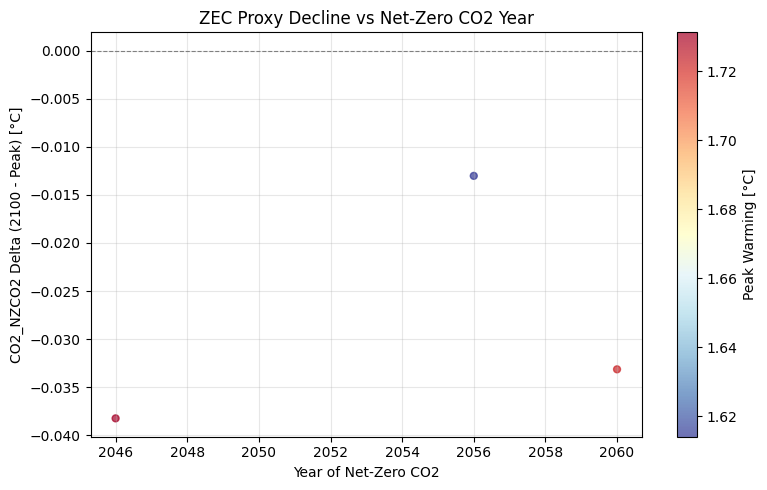

In [12]:
import matplotlib.pyplot as plt

# Merge with stats (median CO2_NZCO2 delta and peak warming per scenario)
plot_data = stats[["GSAT|CO2_NZCO2|delta", "GSAT|ANTHROPOGENIC|peak"]].reset_index().merge(
    netzero_timings[["model", "scenario", "year_netzero_co2"]],
    on=["model", "scenario"],
    how="inner"
).dropna()

# Scatter plot colored by peak warming
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    plot_data["year_netzero_co2"],
    plot_data["GSAT|CO2_NZCO2|delta"],
    c=plot_data["GSAT|ANTHROPOGENIC|peak"],
    cmap="RdYlBu_r",
    alpha=0.7,
    s=25
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Peak Warming [°C]")
ax.set_xlabel("Year of Net-Zero CO2")
ax.set_ylabel("CO2_NZCO2 Delta (2100 - Peak) [°C]")
ax.set_title("ZEC Proxy Decline vs Net-Zero CO2 Year")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()

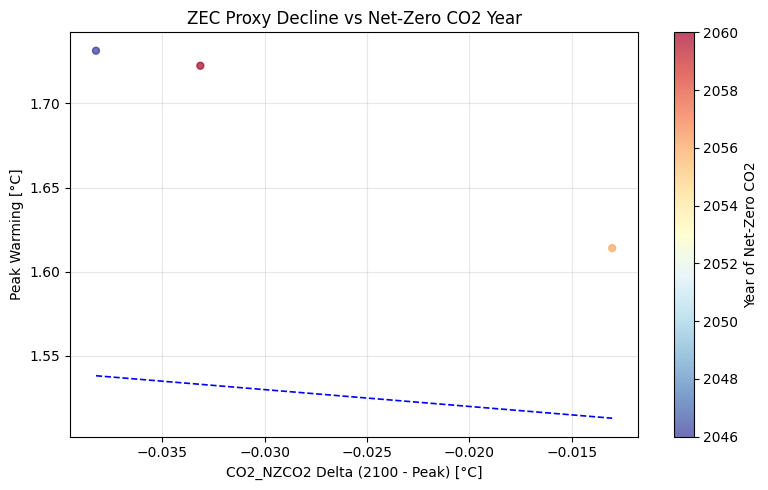

In [13]:
# Merge with stats (median CO2_NZCO2 delta and peak warming per scenario)
plot_data = stats[["GSAT|CO2_NZCO2|delta", "GSAT|ANTHROPOGENIC|peak"]].reset_index().merge(
    netzero_timings[["model", "scenario", "year_netzero_co2"]],
    on=["model", "scenario"],
    how="inner"
).dropna()

# Scatter plot colored by peak warming
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    plot_data["GSAT|CO2_NZCO2|delta"],
    plot_data["GSAT|ANTHROPOGENIC|peak"],
    c=plot_data["year_netzero_co2"],
    cmap="RdYlBu_r",
    alpha=0.7,
    s=25
)
cbar = plt.colorbar(scatter, ax=ax)
ax.set_ylabel("Peak Warming [°C]")
cbar.set_label("Year of Net-Zero CO2")
ax.set_xlabel("CO2_NZCO2 Delta (2100 - Peak) [°C]")
ax.set_title("ZEC Proxy Decline vs Net-Zero CO2 Year")

# Add the 1.5°C iso-line: peak + ZEC_proxy = 1.5
x_line = np.linspace(plot_data["GSAT|CO2_NZCO2|delta"].min(),
                     plot_data["GSAT|CO2_NZCO2|delta"].max(), 100)
y_line = 1.5 - x_line

ax.plot(x_line, y_line, color="blue", linestyle="--", linewidth=1.2)
#ax.legend(fontsize=10)

#ax.set_ylim (1.4, 2.5)
#ax.axhline(1.5, color="gray", linestyle="--", linewidth=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()

## Figure 2

/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_17299/2839848855.py:130: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(PLOT_FOLDER / "503_ZEC_vs_scenario_metrics.png", dpi=300, bbox_inches='tight')


/Users/hoegner/GitHub/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


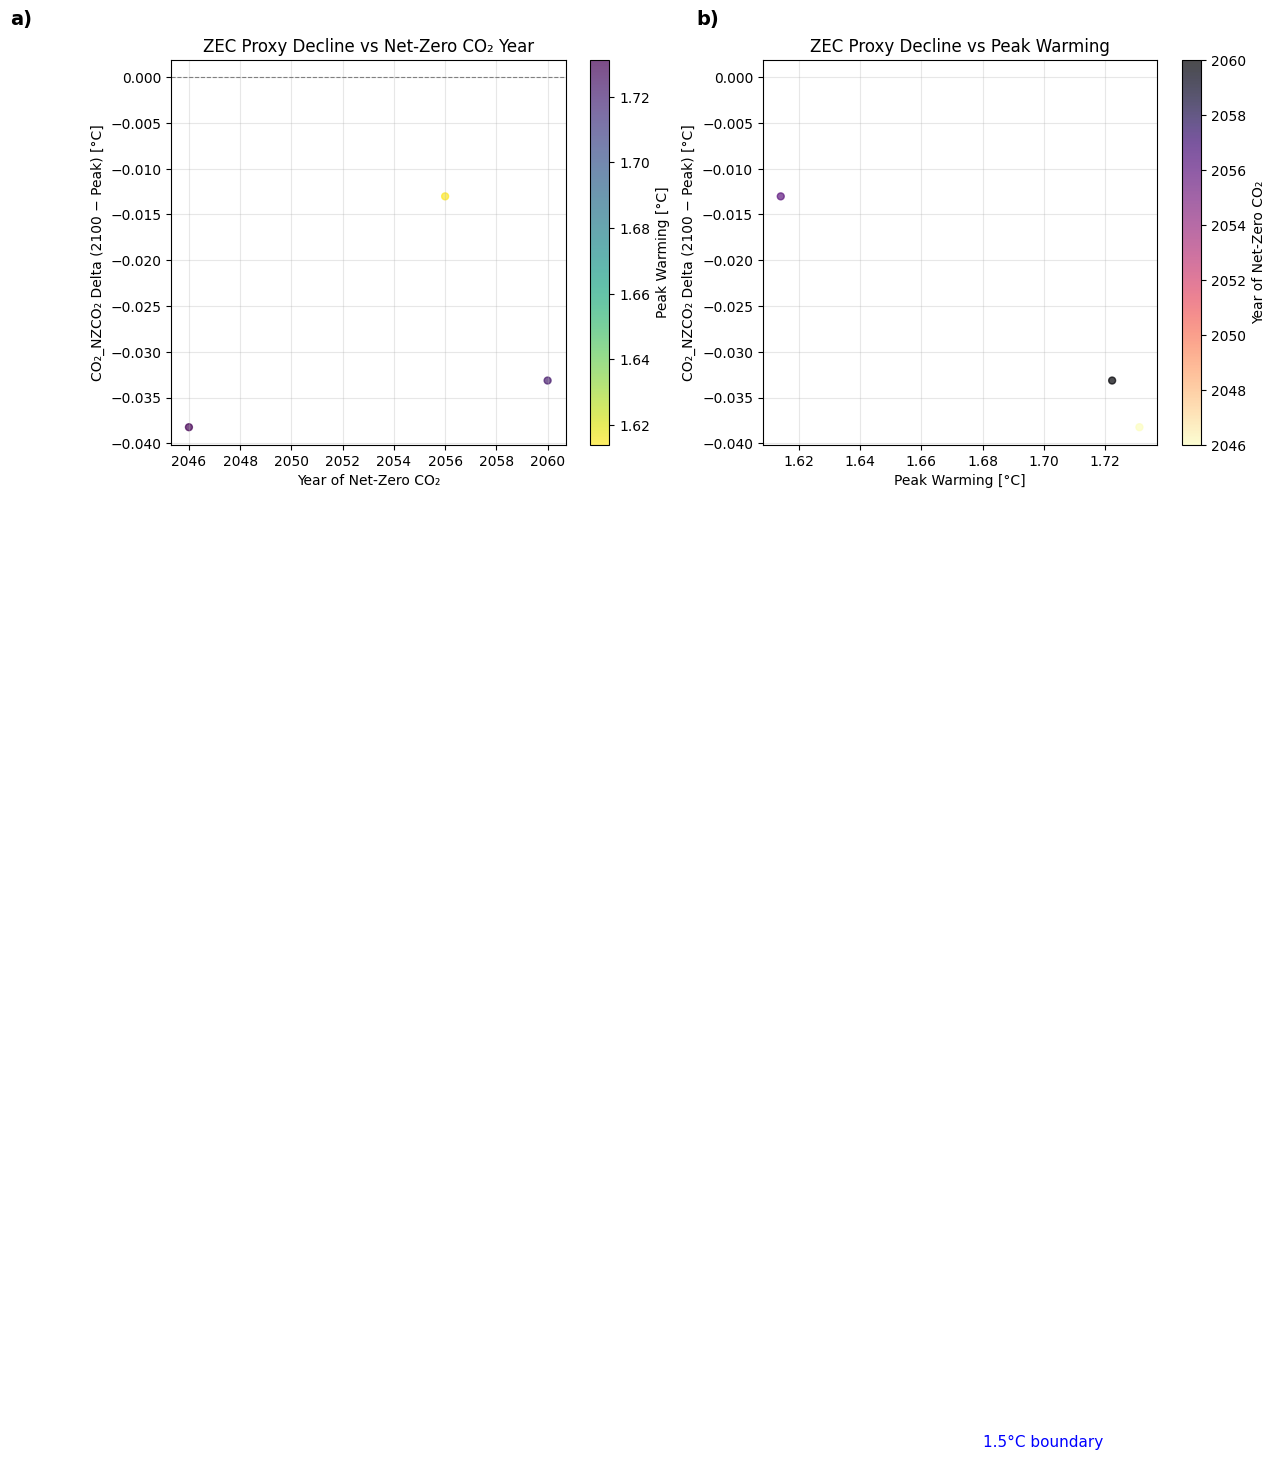

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------

plot_data = (
    stats[["GSAT|CO2_NZCO2|delta", "GSAT|ANTHROPOGENIC|peak"]]
    .reset_index()
    .merge(
        netzero_timings[["model", "scenario", "year_netzero_co2"]],
        on=["model", "scenario"],
        how="inner"
    )
    .dropna()
)

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    constrained_layout=True
)

# ------------------------------------------------------------------
# Panel a)
# ------------------------------------------------------------------

sc1 = ax1.scatter(
    plot_data["year_netzero_co2"],
    plot_data["GSAT|CO2_NZCO2|delta"],
    c=plot_data["GSAT|ANTHROPOGENIC|peak"],
    cmap="viridis_r",
    alpha=0.7,
    s=25
)

cbar1 = fig.colorbar(sc1, ax=ax1)
cbar1.set_label("Peak Warming [°C]")

ax1.set_xlabel("Year of Net-Zero CO₂")
ax1.set_ylabel("CO₂_NZCO₂ Delta (2100 − Peak) [°C]")
ax1.set_title("ZEC Proxy Decline vs Net-Zero CO₂ Year")

ax1.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=0.8
)

ax1.grid(alpha=0.3)

# ------------------------------------------------------------------
# Panel b)
# ------------------------------------------------------------------

sc2 = ax2.scatter(
    plot_data["GSAT|ANTHROPOGENIC|peak"],          # swapped
    plot_data["GSAT|CO2_NZCO2|delta"],   # swapped
    c=plot_data["year_netzero_co2"],
    cmap="magma_r",
    alpha=0.7,
    s=25
)

cbar2 = fig.colorbar(sc2, ax=ax2)
cbar2.set_label("Year of Net-Zero CO₂")

ax2.set_xlabel("Peak Warming [°C]")
ax2.set_ylabel("CO₂_NZCO₂ Delta (2100 − Peak) [°C]")
ax2.set_title("ZEC Proxy Decline vs Peak Warming")

# 1.5°C iso-line:
# peak warming + delta = 1.5°C
x_line = np.linspace(
    plot_data["GSAT|ANTHROPOGENIC|peak"].min(),
    plot_data["GSAT|ANTHROPOGENIC|peak"].max(),
    100
)

y_line = 1.5 - x_line

ax2.plot(
    x_line,
    y_line,
    color="blue",
    linestyle="--",
    linewidth=1.2,
    label="Peak + Δ = 1.5°C"
)

ax2.set_ylim(ax1.get_ylim())

ax2.text(
    1.68, -0.15,   # (x, y) point ON the line
    "1.5°C boundary",
    color="blue",
    fontsize=11,
    va="bottom",
    ha="left"
)

ax2.grid(alpha=0.3)

# ------------------------------------------------------------------
# Panel labels outside axes
# ------------------------------------------------------------------

fig.text(
    0.01, 0.98,
    "a)",
    fontsize=14,
    fontweight="bold",
    va="top"
)

fig.text(
    0.50, 0.98,
    "b)",
    fontsize=14,
    fontweight="bold",
    va="top"
)

plt.savefig(PLOT_FOLDER / "503_ZEC_vs_scenario_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

## Percentile of Percentile Statistics

Calculate the median of medians, p67 of p67, p34 of p34, p5 of p5, p95 of p95 across the delta metrics.

In [15]:
# Define delta columns and percentiles to calculate
delta_cols = [f"GSAT|{c}|delta" for c in COMPONENTS if f"GSAT|{c}|delta" in metrics_df.columns]
PERCENTILES = {"median": 0.5, "p05": 0.05, "p34": 0.34, "p67": 0.67, "p95": 0.95}

# Calculate per-scenario percentiles for each delta column
scenario_percentiles = metrics_df.groupby(["model", "scenario"])[delta_cols].agg(
    [lambda x, q=q: x.quantile(q) for q in PERCENTILES.values()]
)
scenario_percentiles.columns = [f"{col}|{name}" for col in delta_cols for name in PERCENTILES.keys()]

print(f"Calculated percentiles for {len(scenario_percentiles)} scenarios")
scenario_percentiles.head()

Calculated percentiles for 9 scenarios


GSAT|ANTHROPOGENIC|delta|median  \
model       scenario                                                      
AIM/CGE 2.0 SSP1-19                                           -0.267785   
            SSP1-19_NZCO2                                     -0.200802   
            SSP1-19_NZKyoto                                   -0.247481   
AIM/CGE 2.1 CD-LINKS-NPi2020_400                              -0.362958   
            CD-LINKS-NPi2020_400_NZCO2                        -0.203966   

                                        GSAT|ANTHROPOGENIC|delta|p05  \
model       scenario                                                   
AIM/CGE 2.0 SSP1-19                                        -0.394761   
            SSP1-19_NZCO2                                  -0.324194   
            SSP1-19_NZKyoto                                -0.372115   
AIM/CGE 2.1 CD-LINKS-NPi2020_400                           -0.444361   
            CD-LINKS-NPi2020_400_NZCO2                     -0.287272   

                                        GSAT|ANTHROPOGENIC|delta|p34  \
model       scenario                                                   
AIM/CGE 2.0 SSP1-19                                        -0.304798   
            SSP1-19_NZCO2                                  -0.231492   
            SSP1-19_NZKyoto                                -0.282391   
AIM/CGE 2.1 CD-LINKS-NPi2020_400                           -0.392038   
            CD-LINKS-NPi2020_400_NZCO2                     -0.250840   

                                        GSAT|ANTHROPOGENIC|delta|p67  \
model       scenario                                                   
AIM/CGE 2.0 SSP1-19                                        -0.215637   
            SSP1-19_NZCO2                                  -0.133197   
            SSP1-19_NZKyoto                                -0.187296   
AIM/CGE 2.1 CD-LINKS-NPi2020_400                           -0.350869   
            CD-LINKS-NPi2020_400_NZCO2                     -0.176236   

                                        GSAT|ANTHROPOGENIC|delta|p95  \
model       scenario                                                   
AIM/CGE 2.0 SSP1-19                                        -0.107009   
            SSP1-19_NZCO2                                  -0.008911   
            SSP1-19_NZKyoto                                -0.073153   
AIM/CGE 2.1 CD-LINKS-NPi2020_400                           -0.255839   
            CD-LINKS-NPi2020_400_NZCO2                     -0.100973   

                                        GSAT|CO2_NZCO2|delta|median  \
model       scenario                                                  
AIM/CGE 2.0 SSP1-19                                       -0.013020   
            SSP1-19_NZCO2                                 -0.013020   
            SSP1-19_NZKyoto                               -0.013020   
AIM/CGE 2.1 CD-LINKS-NPi2020_400                          -0.038243   
            CD-LINKS-NPi2020_400_NZCO2                    -0.037137   

                                        GSAT|CO2_NZCO2|delta|p05  \
model       scenario                                               
AIM/CGE 2.0 SSP1-19                                    -0.097269   
            SSP1-19_NZCO2                              -0.097269   
            SSP1-19_NZKyoto                            -0.097269   
AIM/CGE 2.1 CD-LINKS-NPi2020_400                       -0.108250   
            CD-LINKS-NPi2020_400_NZCO2                 -0.105039   

                                        GSAT|CO2_NZCO2|delta|p34  \
model       scenario                                               
AIM/CGE 2.0 SSP1-19                                    -0.039421   
            SSP1-19_NZCO2                              -0.039421   
            SSP1-19_NZKyoto                            -0.039421   
AIM/CGE 2.1 CD-LINKS-NPi2020_400                       -0.066640   
            CD-LINKS-NPi2020_400_NZCO2                 -0.066640   

                                        GS

In [16]:
def calc_percentile_of_percentile(scenario_pctl_df, components):
    """Calculate percentile-of-percentile statistics across scenarios."""
    pop = {}
    for comp in components:
        col_base = f"GSAT|{comp}|delta"
        if f"{col_base}|median" in scenario_pctl_df.columns:
            pop[comp] = {
                "median_of_median": scenario_pctl_df[f"{col_base}|median"].median(),
                "p05_of_p05": scenario_pctl_df[f"{col_base}|p05"].quantile(0.05),
                "p34_of_p34": scenario_pctl_df[f"{col_base}|p34"].quantile(0.34),
                "p67_of_p67": scenario_pctl_df[f"{col_base}|p67"].quantile(0.67),
                "p95_of_p95": scenario_pctl_df[f"{col_base}|p95"].quantile(0.95),
            }
    return pop

# All scenarios
pop_all = calc_percentile_of_percentile(scenario_percentiles, COMPONENTS)
pop_all_df = pd.DataFrame(pop_all).T
pop_all_df.index.name = "Component"

print("Percentile of Percentiles - All Scenarios:")
pop_all_df.round(3)

Percentile of Percentiles - All Scenarios:


,median_of_median,p05_of_p05,p34_of_p34,p67_of_p67,p95_of_p95
Component,,,,,
ANTHROPOGENIC,-0.204,-0.436,-0.289,-0.113,-0.002
CO2_NZCO2,-0.033,-0.108,-0.047,0.005,0.055
CO2_Negative,-0.075,-0.219,-0.135,-0.034,0.000
NonCO2_GHG,-0.067,-0.191,-0.097,-0.035,0.034
Residual,0.003,-0.166,-0.042,0.034,0.110


In [17]:
# Filter to scenarios that achieve net-zero Kyoto GHG
nz_kyoto_idx = metrics_df[metrics_df["year_netzero_kyoto_ar6gwp100"].notna()][
    ["model", "scenario"]
].drop_duplicates().set_index(["model", "scenario"]).index

scenario_percentiles_nzkyoto = scenario_percentiles.loc[
    scenario_percentiles.index.isin(nz_kyoto_idx)
]

# Net-zero Kyoto scenarios
pop_nzkyoto = calc_percentile_of_percentile(scenario_percentiles_nzkyoto, COMPONENTS)
pop_nzkyoto_df = pd.DataFrame(pop_nzkyoto).T
pop_nzkyoto_df.index.name = "Component"

print(f"Percentile of Percentiles - Net-Zero Kyoto Scenarios (n={len(scenario_percentiles_nzkyoto)}):")
pop_nzkyoto_df.round(3)

Percentile of Percentiles - Net-Zero Kyoto Scenarios (n=9):


,median_of_median,p05_of_p05,p34_of_p34,p67_of_p67,p95_of_p95
Component,,,,,
ANTHROPOGENIC,-0.204,-0.436,-0.289,-0.113,-0.002
CO2_NZCO2,-0.033,-0.108,-0.047,0.005,0.055
CO2_Negative,-0.075,-0.219,-0.135,-0.034,0.000
NonCO2_GHG,-0.067,-0.191,-0.097,-0.035,0.034
Residual,0.003,-0.166,-0.042,0.034,0.110


## Waterfall Plots

Waterfall plots showing contribution of each component to temperature decline from peak to 2100.

In [18]:
# Calculate scenario-level medians for peak and 2100 (needed for waterfall endpoints)
value_cols = [c for c in metrics_df.columns if c.startswith("GSAT|")]
scenario_medians = metrics_df.groupby(["model", "scenario"])[value_cols].median()
scenario_medians_nzkyoto = scenario_medians.loc[scenario_medians.index.isin(nz_kyoto_idx)]

print(f"All scenarios: {len(scenario_medians)}")
print(f"  Peak (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")
print(f"\nNet-zero Kyoto scenarios: {len(scenario_medians_nzkyoto)}")
print(f"  Peak (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

All scenarios: 9
  Peak (median of medians): 1.722 °C
  2100 (median of medians): 1.399 °C

Net-zero Kyoto scenarios: 9
  Peak (median of medians): 1.722 °C
  2100 (median of medians): 1.399 °C


In [19]:
def create_waterfall_plot(pop_stats, scenario_medians_subset, title, ax):
    # Colors
    color_start = '#2C5F7C'
    color_delta = {
        'CO2_NZCO2': '#8B4513',
        'CO2_Negative': '#228B22',
        'NonCO2_GHG': '#FF8C00',
        'Residual': '#9370DB'
    }
    color_end = '#2E8B57'


    color_start = '#0F0FFF'
    color_delta = {
        'CO2_NZCO2': '#FF0B00',
        'CO2_Negative': '#00E3DB',
        'NonCO2_GHG': '#4CA2FF',
        'Residual': '#C92EB9'
    }
    color_end = '#0F0FFF'



    # Error bar styling
    error_kw = {'ecolor': 'black', 'alpha': 0.5, 'capsize': 4, 'capthick': 1.2}
    
    # Bar styling
    bar_kw = {'width': 0.6, 'edgecolor': 'black', 'linewidth': 0.8}

    # Calculate peak and 2100 statistics
    peak_median = scenario_medians_subset["GSAT|ANTHROPOGENIC|peak"].median()
    peak_p34 = scenario_medians_subset["GSAT|ANTHROPOGENIC|peak"].quantile(0.34)
    peak_p67 = scenario_medians_subset["GSAT|ANTHROPOGENIC|peak"].quantile(0.67)
    
    y2100_median = scenario_medians_subset["GSAT|ANTHROPOGENIC|2100"].median()
    y2100_p34 = scenario_medians_subset["GSAT|ANTHROPOGENIC|2100"].quantile(0.34)
    y2100_p67 = scenario_medians_subset["GSAT|ANTHROPOGENIC|2100"].quantile(0.67)
    
    # Bar positions
    x_positions = [0, 1, 2, 3, 4, 5]
    labels = ["Peak\n[ANTHROPOGENIC]", "ZEC*", "CO$_2$\nNeg", "Non-CO$_2$\nGHG", "Resid.", "2100\n[ANTHROPOGENIC]"]
    
    # Plot peak bar
    ax.bar(0, peak_median, color=color_start,
           yerr=[[peak_median - peak_p34], [peak_p67 - peak_median]],
           error_kw=error_kw, **bar_kw)
    
    # Plot delta bars (stacked waterfall)
    bottom = peak_median
    delta_components = ['CO2_NZCO2', 'CO2_Negative', 'NonCO2_GHG', 'Residual']
    
    for i, comp in enumerate(delta_components):
        if comp in pop_stats:
            delta_med = pop_stats[comp]["median_of_median"]
            delta_p34 = pop_stats[comp]["p34_of_p34"]
            delta_p67 = pop_stats[comp]["p67_of_p67"]
            
            ax.bar(i + 1, delta_med, bottom=bottom, color=color_delta[comp],
                   yerr=[[delta_med - delta_p34], [delta_p67 - delta_med]],
                   error_kw=error_kw, **bar_kw)
            bottom += delta_med
    
    # Plot 2100 bar
    ax.bar(5, y2100_median, color=color_end,
           yerr=[[y2100_median - y2100_p34], [y2100_p67 - y2100_median]],
           error_kw=error_kw, **bar_kw)
    
    # Formatting
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylabel("GSAT (°C)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    
    return ax

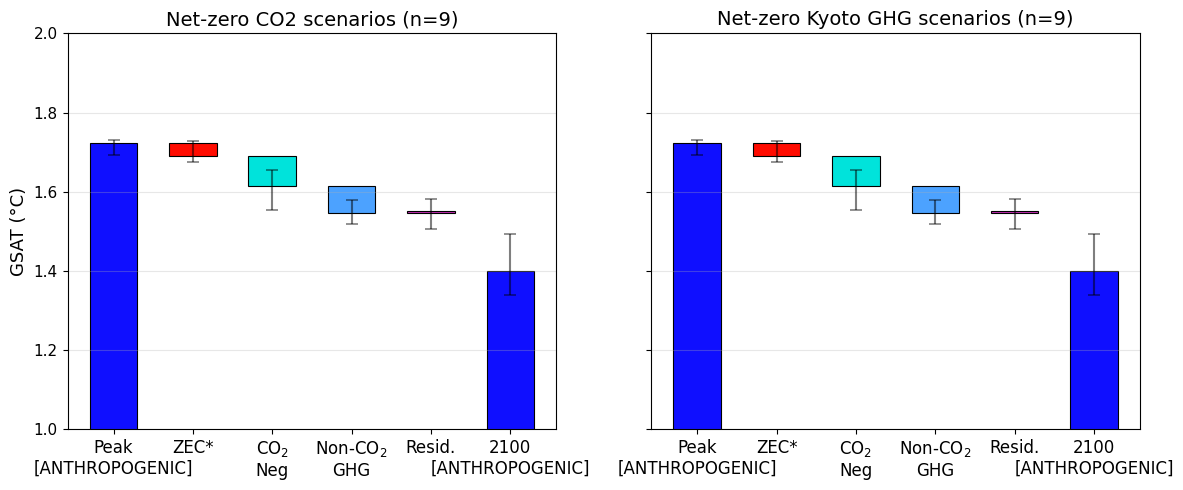

In [20]:
# Create waterfall plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot 1: All scenarios
create_waterfall_plot(
    pop_all,
    scenario_medians,
    f"Net-zero CO2 scenarios (n={len(scenario_medians)})",
    axes[0]
)

# Plot 2: Net-zero Kyoto scenarios
create_waterfall_plot(
    pop_nzkyoto,
    scenario_medians_nzkyoto,
    f"Net-zero Kyoto GHG scenarios (n={len(scenario_medians_nzkyoto)})",
    axes[1]
)

# Set y-axis limits
axes[0].set_ylim(1, 2)
axes[1].set_ylim(1, 2)

# Common y-axis label only on left
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "503_waterfall_contributions.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Summary comparison table
summary = pd.DataFrame({
    "NZCO2": pop_all_df["median_of_median"],
    "NZGHG": pop_nzkyoto_df["median_of_median"],
    "Difference": pop_nzkyoto_df["median_of_median"] - pop_all_df["median_of_median"]
})

print("Median of Medians Comparison (°C):")
summary.round(3)

Median of Medians Comparison (°C):


,NZCO2,NZGHG,Difference
Component,,,
ANTHROPOGENIC,-0.204,-0.204,0.0
CO2_NZCO2,-0.033,-0.033,0.0
CO2_Negative,-0.075,-0.075,0.0
NonCO2_GHG,-0.067,-0.067,0.0
Residual,0.003,0.003,0.0


ANTHROPOGENIC / NZCO2: ZEC for scenarios that achieve NZCO2
ANTHROPOGENIC / NZGHG: ZEC for scenarios that achieve NZGHG
--> Difference: ZEC increase due to non-CO2 mitigation efforts (but also possibly higher negative CO2 emissions in this scenario set; not a neutral selection)

CO2_NZCO2 / NZCO2: contribution of CO2 to decline for NZCO2 scenarios
CO2_NZCO2 / NZGHG: contribution of CO2 to decline for NZGHG scenarios

CO2_Negative / NZCO2: contribution of negative CO2 emissions to decline for NZCO2 scenarios
CO2_Negative / NZGHG: contribution of negative CO2 emissions to decline for NZGHG scenarios

NonCO2_GHG / NZCO2: contribution of non-CO2 GHGs to decline for NZCO2 scenarios
NonCO2_GHG / NZGHG: contribution of non-CO2 GHGs to decline for NZGHG scenarios
--> Difference: additional mitigation effects